# 03 – Modelling

Train and evaluate classifiers to predict stress / affect state from biosignal features.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# Load all CSV files — column names are read directly from each file's header
data_dir = Path('../data/raw/data')

csv_files = glob.glob(str(data_dir / '**/*.csv'), recursive=True)
dfs = {}
for f in sorted(csv_files):
    key = Path(f).stem
    dfs[key] = pd.read_csv(f, index_col=0)
    print(f"{Path(f).relative_to(data_dir)}  →  {dfs[key].shape}")

df = dfs['HR_data'].dropna()
print(f'\nDataset: {df.shape[0]} rows, {df.shape[1]} columns')

HR_data.csv  →  (312, 67)
dataset/D1_1/ID_1/round_1/phase1/BVP.csv  →  (28624, 2)
dataset/D1_1/ID_1/round_1/phase1/EDA.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/HR.csv  →  (448, 2)
dataset/D1_1/ID_1/round_1/phase1/TEMP.csv  →  (1789, 2)
dataset/D1_1/ID_1/round_1/phase1/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_1/phase2/BVP.csv  →  (25081, 2)
dataset/D1_1/ID_1/round_1/phase2/EDA.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/HR.csv  →  (392, 2)
dataset/D1_1/ID_1/round_1/phase2/TEMP.csv  →  (1567, 2)
dataset/D1_1/ID_1/round_1/phase2/response.csv  →  (1, 16)
dataset/D1_1/ID_1/round_1/phase3/BVP.csv  →  (23691, 2)
dataset/D1_1/ID_1/round_1/phase3/EDA.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/HR.csv  →  (370, 2)
dataset/D1_1/ID_1/round_1/phase3/TEMP.csv  →  (1480, 2)
dataset/D1_1/ID_1/round_1/phase3/response.csv  →  (1, 15)
dataset/D1_1/ID_1/round_2/phase1/BVP.csv  →  (19565, 2)
dataset/D1_1/ID_1/round_2/phase1/EDA.csv  →  (1223, 2)
dataset/D1_1/ID_1/round_2/pha

In [3]:
# Identify biosignal columns dynamically — numeric, excluding metadata
meta_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'Cohort']
numeric_cols = df.select_dtypes(include='number').columns.tolist()
biosignal_cols = [c for c in numeric_cols if c not in meta_cols]

# Variance-based feature selection
variances = df[biosignal_cols].var()
feature_cols = variances[variances > 0.01].index.tolist()
print(f'Features passing variance threshold: {len(feature_cols)}')

# Encode phase as target label
le = LabelEncoder()
df['phase_encoded'] = le.fit_transform(df['Phase'])
print(f'Phase classes: {list(le.classes_)}')

Features passing variance threshold: 47
Phase classes: ['phase1', 'phase2', 'phase3']


/var/folders/3b/_701tnqj0_545vycfpjds_1r0000gn/T/ipykernel_31380/4190646736.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['phase_encoded'] = le.fit_transform(df['Phase'])


In [4]:
# Normalise features and split data
X = df[feature_cols].copy()
y = df['phase_encoded']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 245, Test: 62


In [5]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'f1_weighted': f1_score(y_test, rf_pred, average='weighted'),
}
print('Random Forest:', rf_metrics)
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest: {'accuracy': 0.5483870967741935, 'f1_weighted': 0.5472558688452601}
              precision    recall  f1-score   support

      phase1       0.52      0.60      0.56        20
      phase2       0.65      0.62      0.63        21
      phase3       0.47      0.43      0.45        21

    accuracy                           0.55        62
   macro avg       0.55      0.55      0.55        62
weighted avg       0.55      0.55      0.55        62



In [6]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_metrics = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'f1_weighted': f1_score(y_test, lr_pred, average='weighted'),
}
print('Logistic Regression:', lr_metrics)
print(classification_report(y_test, lr_pred, target_names=le.classes_))

Logistic Regression: {'accuracy': 0.4838709677419355, 'f1_weighted': 0.48980795567442226}
              precision    recall  f1-score   support

      phase1       0.42      0.50      0.45        20
      phase2       0.69      0.52      0.59        21
      phase3       0.41      0.43      0.42        21

    accuracy                           0.48        62
   macro avg       0.50      0.48      0.49        62
weighted avg       0.51      0.48      0.49        62



In [7]:
# 5-fold cross-validation
cv_clf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_result = cross_validate(cv_clf, X_scaled, y, cv=5, scoring='f1_weighted')
scores = cv_result['test_score']
print(f'CV F1 (weighted): {scores.mean():.3f} ± {scores.std():.3f}')

CV F1 (weighted): 0.570 ± 0.026


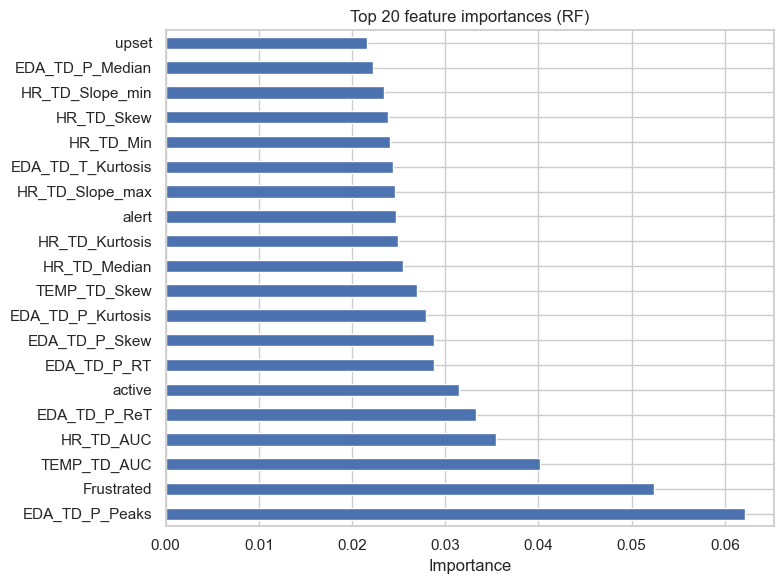

In [8]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(20).plot(kind='barh', figsize=(8, 6), title='Top 20 feature importances (RF)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/figures/feature_importances.png', dpi=150)
plt.show()

In [9]:
# Save metrics summary
summary = pd.DataFrame([rf_metrics, lr_metrics], index=['RandomForest', 'LogisticRegression'])
summary.to_csv('../results/tables/model_metrics.csv')
summary

,accuracy,f1_weighted
RandomForest,0.548387,0.547256
LogisticRegression,0.483871,0.489808
